<a href="https://colab.research.google.com/github/MoeTahech/real-fake-face-detection-thesis/blob/main/notebooks/05_adversarial_robustness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 — Phase 5: Adversarial Robustness

Tests whether the fine-tuned ResNet18 (Phase 2) can be fooled by small,
deliberately crafted pixel perturbations — imperceptible or near-imperceptible
to a human, but designed to flip the model's prediction.

Two standard white-box attacks are used:
- **FGSM** (Fast Gradient Sign Method) — a single-step attack, fast but weaker
- **PGD** (Projected Gradient Descent) — an iterative, stronger version of FGSM

For a range of perturbation strengths (epsilon), we measure how much accuracy
drops — this is the standard way robustness is reported in the literature
(see SOTA review, Section 8, "Adversarial robustness").

Requires `02_finetuning.ipynb` to have been run at least once (so
`best_model_finetuned.pth` exists in Drive).

Runtime → Change runtime type → GPU, then run cells top to bottom.

### Step 1 — Confirm you have a GPU

In [1]:
!nvidia-smi

Sun Aug  9 00:33:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Step 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = '/content/drive/MyDrive/thesis_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print("Checkpoints will be loaded from:", CHECKPOINT_DIR)

Mounted at /content/drive
Checkpoints will be loaded from: /content/drive/MyDrive/thesis_checkpoints


### Step 3 — Get the Dataset



In [3]:
import os

os.environ["KAGGLE_API_TOKEN"] = "YOUR_KAGGLE_API_TOKEN_HERE"

### Step 4 — Download and link the dataset (needed to get test images)

In [4]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -q 140k-real-and-fake-faces.zip -d data_raw

def find_split_root(root="data_raw"):
    for dirpath, dirnames, filenames in os.walk(root):
        if "train" in dirnames:
            train_path = os.path.join(dirpath, "train")
            if os.path.isdir(os.path.join(train_path, "real")) and os.path.isdir(os.path.join(train_path, "fake")):
                return dirpath
    return None

base = find_split_root("data_raw")
base_abs = os.path.abspath(base)
print("Found dataset root:", base_abs)

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [02:57<00:00, 22.7MB/s]

Found dataset root: /content/data_raw/real_vs_fake/real-vs-fake


### Step 5 — Load the fine-tuned model (Phase 2)

This is the model we're attacking — the strongest single model from Phases 1-4.

In [5]:
import torch, torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(f"{CHECKPOINT_DIR}/best_model_finetuned.pth", map_location=device)
class_to_idx = checkpoint["class_to_idx"]
real_idx = class_to_idx["real"]
print("Class mapping:", class_to_idx)

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(checkpoint["model_state"])
model.to(device).eval()
print("Model loaded.")

Class mapping: {'fake': 0, 'real': 1}
Model loaded.


### Step 6 — Build a small evaluation subset

Adversarial attacks are much slower than normal inference (each attack step
requires a forward + backward pass). We use a manageable subset (e.g. 500
images per class) rather than the full 20,000-image test set — standard
practice for adversarial evaluation given the extra compute cost.

In [6]:
import os, random
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# NOTE: no normalization baked into this transform — we normalize separately
# inside the attack functions, since perturbations must be computed in [0,1]
# pixel space, not normalized space.
to_tensor = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # produces [0, 1] range
])

class FaceSubset(Dataset):
    def __init__(self, root, class_to_idx, n_per_class=500, seed=42):
        self.samples = []
        rng = random.Random(seed)
        for cls_name, idx in class_to_idx.items():
            cls_dir = os.path.join(root, cls_name)
            files = os.listdir(cls_dir)
            rng.shuffle(files)
            for f in files[:n_per_class]:
                self.samples.append((os.path.join(cls_dir, f), idx))
        rng.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        image = Image.open(path).convert("RGB")
        return to_tensor(image), label

test_dir = f"{base_abs}/test"
eval_set = FaceSubset(test_dir, class_to_idx, n_per_class=500)
print("Evaluation subset size:", len(eval_set))

from torch.utils.data import DataLoader
eval_loader = DataLoader(eval_set, batch_size=32, shuffle=False, num_workers=2)

Evaluation subset size: 1000


### Step 7 — Define the attacks (FGSM and PGD) and a clean-accuracy baseline

Both attacks operate in raw [0,1] pixel space (perturbation bounded by epsilon
there), then normalize internally before feeding the model — this keeps
epsilon values interpretable as "fraction of the 0-255 pixel range."

`epsilon=0` is included as a sanity check — it should reproduce the model's
normal (unattacked) accuracy from Phase 2.

In [7]:
import torch.nn.functional as F

def normalize_batch(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(1, 3, 1, 1)
    return (x - mean) / std

def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().to(device).requires_grad_(True)
    labels = labels.to(device)

    outputs = model(normalize_batch(images))
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()

    perturbed = images + epsilon * images.grad.sign()
    perturbed = torch.clamp(perturbed, 0, 1).detach()
    return perturbed

def pgd_attack(model, images, labels, epsilon, alpha=0.01, steps=10):
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    original = images.clone().detach()

    perturbed = images.clone().detach()
    for _ in range(steps):
        perturbed.requires_grad_(True)
        outputs = model(normalize_batch(perturbed))
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()

        perturbed = perturbed + alpha * perturbed.grad.sign()
        # Project back into the epsilon-ball around the original image
        perturbation = torch.clamp(perturbed - original, -epsilon, epsilon)
        perturbed = torch.clamp(original + perturbation, 0, 1).detach()

    return perturbed

print("Attack functions ready.")

Attack functions ready.


### Step 8 — Run the robustness evaluation across several epsilon values

This is the main experiment: for each attack strength (epsilon), attack every
image in the evaluation subset and measure accuracy. Epsilon is in [0,1] pixel
space — 0.03 roughly corresponds to a change of about 8 out of 255 grey levels
per pixel, typically subtle to a human eye; 0.1 is a much larger, sometimes
visible perturbation.

This will take a while (each attacked batch needs a forward+backward pass per
PGD step) — expect noticeably longer than a normal evaluation pass.

In [8]:
from sklearn.metrics import accuracy_score

epsilons = [0.0, 0.01, 0.03, 0.05, 0.1]

def evaluate_under_attack(attack_fn, epsilon):
    all_labels, all_preds = [], []
    for images, labels in eval_loader:
        if epsilon == 0.0:
            attacked = images.to(device)
        else:
            attacked = attack_fn(model, images, labels, epsilon)
        with torch.no_grad():
            outputs = model(normalize_batch(attacked))
            preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
    return accuracy_score(all_labels, all_preds)

print(f"{'Epsilon':<10} {'Clean/FGSM Acc':<16} {'PGD Acc':<10}")
results = []
for eps in epsilons:
    fgsm_acc = evaluate_under_attack(fgsm_attack, eps)
    pgd_acc = evaluate_under_attack(pgd_attack, eps) if eps > 0 else fgsm_acc
    results.append((eps, fgsm_acc, pgd_acc))
    print(f"{eps:<10} {fgsm_acc:<16.4f} {pgd_acc:<10.4f}")

Epsilon    Clean/FGSM Acc   PGD Acc   
0.0        0.9900           0.9900    
0.01       0.0000           0.0000    
0.03       0.0010           0.0000    
0.05       0.1320           0.0000    
0.1        0.4490           0.0000    


### Step 9 — Plot the robustness curve

A steep drop as epsilon increases indicates low adversarial robustness — this
plot is a standard figure to include directly in a thesis's robustness section.

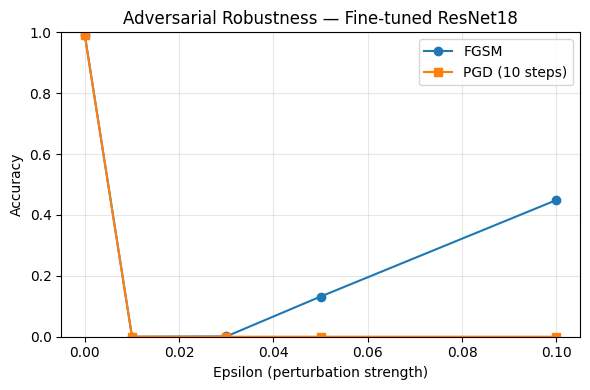

In [9]:
import matplotlib.pyplot as plt

eps_vals = [r[0] for r in results]
fgsm_accs = [r[1] for r in results]
pgd_accs = [r[2] for r in results]

plt.figure(figsize=(6, 4))
plt.plot(eps_vals, fgsm_accs, marker='o', label='FGSM')
plt.plot(eps_vals, pgd_accs, marker='s', label='PGD (10 steps)')
plt.xlabel('Epsilon (perturbation strength)')
plt.ylabel('Accuracy')
plt.title('Adversarial Robustness — Fine-tuned ResNet18')
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 10 (optional) — Visualize one attacked example

Shows a single face image before and after PGD perturbation at a chosen
epsilon, alongside the model's prediction on each — useful for illustrating
"the image looks almost identical, but the model is fooled" in your report.

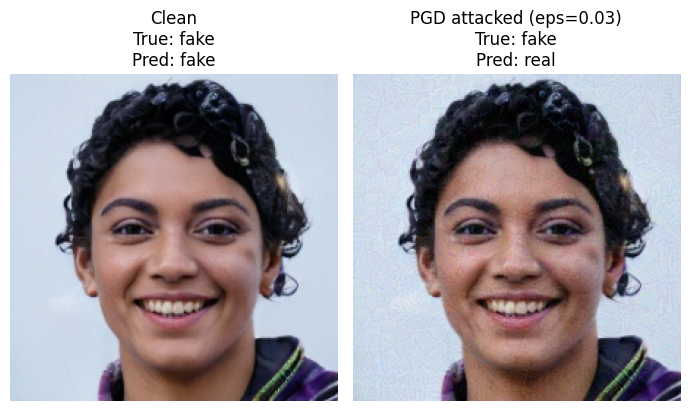

In [10]:
import matplotlib.pyplot as plt

images, labels = next(iter(eval_loader))
image, label = images[0:1], labels[0:1]

eps_demo = 0.03
perturbed = pgd_attack(model, image, label, eps_demo)

with torch.no_grad():
    clean_pred = model(normalize_batch(image.to(device))).argmax(dim=1).item()
    adv_pred = model(normalize_batch(perturbed)).argmax(dim=1).item()

idx_to_class = {v: k for k, v in class_to_idx.items()}
fig, axes = plt.subplots(1, 2, figsize=(7, 4))
axes[0].imshow(image[0].permute(1, 2, 0).cpu().numpy())
axes[0].set_title(f"Clean\nTrue: {idx_to_class[label.item()]}\nPred: {idx_to_class[clean_pred]}")
axes[0].axis("off")
axes[1].imshow(perturbed[0].permute(1, 2, 0).cpu().numpy())
axes[1].set_title(f"PGD attacked (eps={eps_demo})\nTrue: {idx_to_class[label.item()]}\nPred: {idx_to_class[adv_pred]}")
axes[1].axis("off")
plt.tight_layout()
plt.show()